## Görüntülerden Öznitelik Çıkarma Nedir?
- Görüntü verileri, milyonlarca pikselden oluşan yüksek boyutlu verilerdir.
- Amaç: Görseli daha az boyutlu ama anlamlı özelliklerle temsil etmek.
- Görüntüdeki desen, renk, kenar, köşe gibi unsurlar öznitelik olarak çıkarılır.
- Bu öznitelikler, sınıflandırma, tanıma veya tespit modellerine girdi olur.

## Görüntülerden Çıkarılabilecek Temel Öznitelikler
- Renk özellikleri: RGB, HSV,  renk histogramı
- Kenar ve köşe özellikleri: Sobel, Canny, Harris Corner
- Doku özellikleri: Gabor filtreleri, Local Binary Patterns (LBP)
- Şekil özellikleri: Kontur, momentler, objenin boyut oranları
- Bu öznitelikler bir araya gelerek göreslin "parmak izi"ni oluşturur.

## Klasik Öznitelik Çıkarma Yöntemleri
- SIFT (Scale-Invariant Feature Transform): Nesne tanımada ölçek ve döndürme farkına dayanıklı.
- SURF (Speeded-Up Robust Features): SIFT'e benzer ama daha hızlıdır.
- HOG (Histogram of Oriented Gradients): Kenar yönelimlerine dayalı öznitelikler çıkarır.
- ORB (Oriented FAST and Rotated BRIEF): Hafif, gerçek zamanlı uygulamalra uygun bir yöntem.

## Derin Öğrenme ile Otomatik Öznitelik Çıkarma
- Klasik yöntemlerde öznitelikler insan eliyle tasarlanır.
- Derin öğrenmede (CNN) model öznitelikleri kendisi öğrenir.
- Alt katmanlar: kenarlar, renk geçişleri
- Orta katmanlar: şekiller, desenler
- Üst katmanlar: anlamlı objeler (ör. yüz, araba, kedi)
- Sonuç: Daha güçlü ve genellenebilir temsiller.

# Görüntülerden Öznitelik Çıkarma
Amaç: ham piksel yerine görüntüyü anlamlı sayısal temsillerle ifade etmek.
---
Adım adım:
1. Renk Özellikleri: Görseldeki R-G-B kanal dağılımlarını renk histogramı ile çıkartalım
2. Kenar Özellikleri: Sobel filtresi ile yatay ve dikey kenarları tespit edelim
3. Köşe Özellikleri: Görseldeki belirgin köşe noktalarını bul
4. Doku Özellikleri: Local Binary Pattern (LBP) yöntemiyle yüzey desenlerini analiz et.

In [2]:
import cv2 # görüntü işleme kütüphanesi opencv
import numpy as np #sayısal işlemler
import matplotlib.pyplot as plt
from skimage import data #hazır test görüntüsü al
from skimage.feature import local_binary_pattern
from skimage.measure import moments_hu,label,regionprops
from skimage.color import rgb2gray

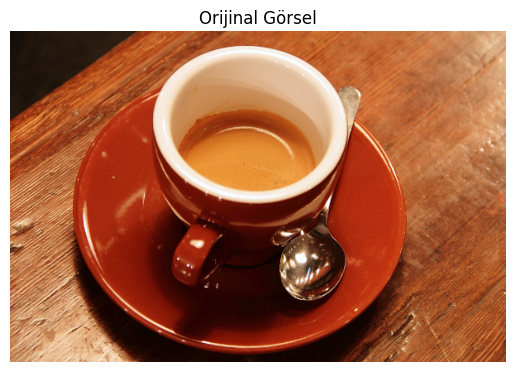

In [3]:
# hazır görüntüyü yükle
image = data.coffee()
plt.imshow(image)
plt.title("Orijinal Görsel")
plt.axis("off")
plt.show()

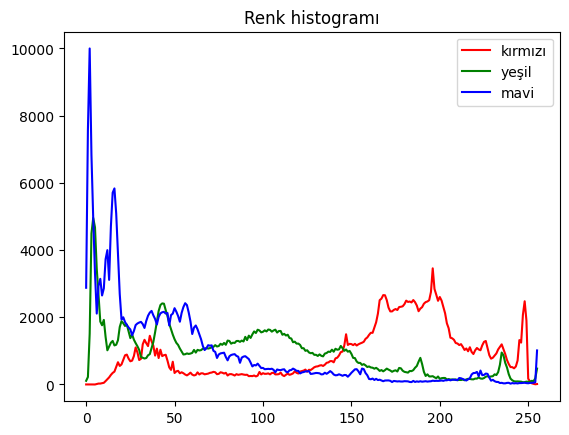

In [7]:
# renk özellikleri
# renk histogramı: R G B kannalarındaki renk dağılımını öznitelik olarak alır
hist_r = cv2.calcHist([image],[0],None,[256],[0,256])
hist_g = cv2.calcHist([image],[1],None,[256],[0,256])
hist_b = cv2.calcHist([image],[2],None,[256],[0,256])

plt.figure()
plt.plot(hist_r,color="red",label="kırmızı")
plt.plot(hist_g,color="green",label="yeşil")
plt.plot(hist_b,color="blue",label="mavi")
plt.title("Renk histogramı")
plt.legend()
plt.show()

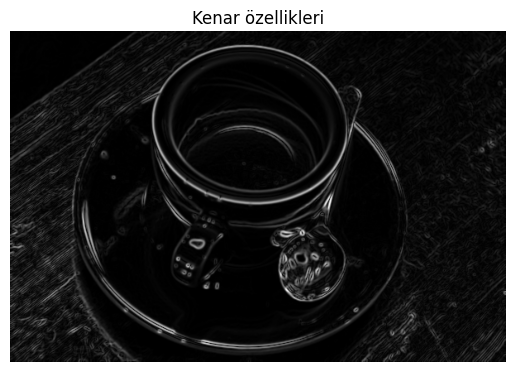

In [8]:
# kenar özellikleri
# sobel filtresiyle yatay ve dikey kenarları bulalım
gray = rgb2gray(image) #görüntüyü gri tona çevir
edges_x = cv2.Sobel(gray,cv2.CV_64F,1,0,ksize=5) #yatay kenarları
edges_y = cv2.Sobel(gray,cv2.CV_64F,0,1,ksize=5) #dikey kenarları
edges = np.sqrt(edges_x**2 + edges_y**2) # her iki yönü birleştir

plt.imshow(edges,cmap="gray")
plt.title("Kenar özellikleri")
plt.axis("off")
plt.show()

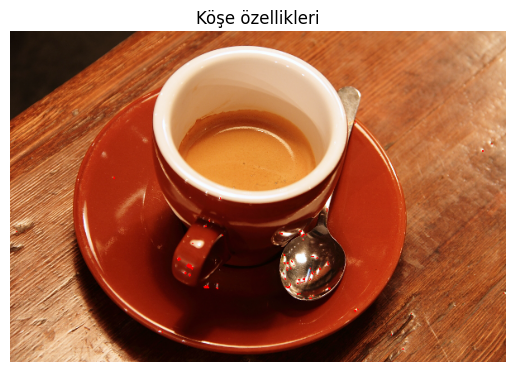

In [13]:
# köşe özellikleri
gray_cv = np.float32(rgb2gray(image))

dst = cv2.cornerHarris(gray_cv, blockSize = 4, ksize= 5, k = 0.2)

#gürültüyü azaltmak için köşe haritasını genişlet
sdt = cv2.dilate(dst,None)

#daha yüksek eşik değeri
threshold = 0.03*dst.max()
corner_mask = dst > threshold

#köşeleri renklendir
image_corners = image.copy()
image_corners[corner_mask] = [255,0,0] #kırmızı köşeler

plt.imshow(image_corners)
plt.title("Köşe özellikleri")
plt.axis("off")
plt.show()

/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


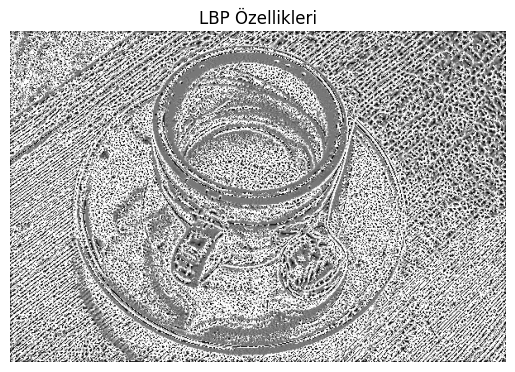

In [14]:
# doku özellikleri
# local binary pattern
radius = 2 # komşuluk yarı çapı
n_points = 8 * radius # komşu sayısı
lbp = local_binary_pattern(gray,n_points,radius,method="uniform")

# görselleştir
plt.imshow(lbp,cmap="gray")
plt.title("LBP Özellikleri")
plt.axis("off")
plt.show()